# Custom model

In [ ]:
import tensorflow as tf
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import random
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# --- Hyperparameter Tuning Imports ---
import keras_tuner as kt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop, Adadelta, Adagrad
from tensorflow.keras.regularizers import L1, L2

# --- Project Root Discovery ---
project_root = Path.cwd()
while not (project_root / ".git").exists():
    if project_root == project_root.parent:
        break
    project_root = project_root.parent
    
%cd ..
# Import custom components from your local files
from src.model import SparseCategoricalF1Score
from src.dataset import load_split

# --- Paths to data ---
wikiart_path = project_root / "data"
train_dir = wikiart_path / "train"
val_dir = wikiart_path / "validation"
test_dir = wikiart_path / "test"

# --- Check paths exist ---
for path in [train_dir, val_dir, test_dir]:
    if not path.exists():
        print(f"Warning: {path} does not exist!")

print(f"Project root: {project_root}")
print(f"WikiArt path: {wikiart_path}")

# --- Dataset parameters ---
BATCH_SIZE = 64
IMG_SIZE = (50, 50)
IMG_SHAPE = IMG_SIZE + (3,)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

c:\Users\luisb\OneDrive\Documentos\Projects_portfolio\DeepLearning-NOVAIMS2026
Project root: c:\Users\luisb\OneDrive\Documentos\Projects_portfolio\DeepLearning-NOVAIMS2026
WikiArt path: c:\Users\luisb\OneDrive\Documentos\Projects_portfolio\DeepLearning-NOVAIMS2026\data


c:\Users\luisb\anaconda3\envs\DeepLearning\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# Load datasets using your dataset.py logic
# For a Perceptron, we don't usually need heavy augmentation, so augment=False
train_ds, class_names = load_split(train_dir, IMG_SIZE, BATCH_SIZE, augment=False)
val_ds, _ = load_split(val_dir, IMG_SIZE, BATCH_SIZE, augment=False)
test_ds, _ = load_split(test_dir, IMG_SIZE, BATCH_SIZE, augment=False)

num_classes = len(class_names)
print(f"Loaded {num_classes} classes.")

Found 9231 files belonging to 23 classes.
Found 1969 files belonging to 23 classes.
Found 2000 files belonging to 23 classes.
Loaded 23 classes.


In [3]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Model Evaluation Function

Define a reusable comprehensive evaluation function that includes training history plots, confusion matrix, and detailed metrics.

In [18]:
def evaluate_model_comprehensive(model, history, train_ds, val_ds, test_ds, class_names):
    """
    Comprehensive model evaluation function that plots training history, 
    confusion matrix, and prints detailed metrics for train, validation, and test sets.
    
    Parameters:
    -----------
    model : tf.keras.Model
        Trained model to evaluate
    history : tf.keras.callbacks.History
        Training history object from model.fit()
    train_ds : tf.data.Dataset
        Training dataset
    val_ds : tf.data.Dataset
        Validation dataset
    test_ds : tf.data.Dataset
        Test dataset
    class_names : list
        List of class names for the confusion matrix labels
    """
    
    # 1. Plot Training History
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['f1_macro'], label='Train F1')
    plt.plot(history.history['val_f1_macro'], label='Val F1')
    plt.title('Macro F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 2. Helper function to evaluate a dataset
    def evaluate_dataset(dataset, dataset_name):
        """Helper function to compute and display confusion matrix and classification report."""
        print("\n" + "="*60)
        print(f"Evaluating {dataset_name} Set")
        print("="*60)
        
        y_true = []
        y_pred = []

        for imgs, labels in dataset:
            preds = model.predict(imgs, verbose=0)
            y_true.extend(labels.numpy())
            y_pred.extend(np.argmax(preds, axis=1))

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        
        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Plot confusion matrix
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'Artist Confusion Matrix - {dataset_name} Set')
        plt.tight_layout()
        plt.show()

        # Print classification report
        print(f"\nClassification Report ({dataset_name} Set):")
        print(classification_report(y_true, y_pred, target_names=class_names))
        
        return y_true, y_pred

    # 3. Evaluate all three datasets
    print("\n" + "="*60)
    print("COMPREHENSIVE MODEL EVALUATION")
    print("="*60)
    
    train_true, train_pred = evaluate_dataset(train_ds, "Train")
    val_true, val_pred = evaluate_dataset(val_ds, "Validation")
    test_true, test_pred = evaluate_dataset(test_ds, "Test")

    # 4. Final Test Set Evaluation with model.evaluate()
    print("\n" + "="*60)
    print("Final Evaluation Metrics")
    print("="*60)
    results = model.evaluate(test_ds, verbose=0)
    print(f"Test Loss: {results[0]:.4f}")
    print(f"Test F1-Score: {results[1]:.4f}")


## Setup Training Callbacks

Define a reusable function to configure callbacks for training with early stopping and learning rate scheduling.

In [5]:
def setup_callbacks(monitor_metric='val_f1_macro', early_stopping_patience=6, 
                   lr_factor=0.1, lr_patience=3, min_lr=1e-6):
    """
    Create a list of callbacks for model training.
    
    Parameters:
    -----------
    monitor_metric : str
        Metric to monitor for early stopping and learning rate reduction (default: 'val_f1_macro')
    early_stopping_patience : int
        Number of epochs with no improvement after which training will be stopped (default: 6)
    lr_factor : float
        Factor by which learning rate will be multiplied (default: 0.1)
    lr_patience : int
        Number of epochs with no improvement after which learning rate will be reduced (default: 3)
    min_lr : float
        Minimum learning rate threshold (default: 1e-6)
    
    Returns:
    --------
    list : List of Keras callbacks
    """
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor_metric, 
            mode='max', 
            patience=early_stopping_patience, 
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=monitor_metric,
            factor=lr_factor,
            patience=lr_patience,
            min_lr=min_lr,
            verbose=1
        )
    ]
    return callbacks


# Under Fitting model

In [ ]:
model_uf = tf.keras.Sequential()
model_uf.add(tf.keras.layers.Conv2D(32, (5,5), activation='relu', input_shape=IMG_SHAPE))
model_uf.add(tf.keras.layers.MaxPooling2D((5,5)))
model_uf.add(tf.keras.layers.Flatten())
model_uf.add(tf.keras.layers.Dense(128, activation='relu'))

model_uf.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
model_uf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=[SparseCategoricalF1Score(num_classes, name="f1_macro")])
model_uf.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 46, 46, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2592)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       331,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,303 (1.29 MB)

 Trainable params: 337,303 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Setup Callbacks using the helper function
callbacks = setup_callbacks(
    monitor_metric='val_f1_macro',
    early_stopping_patience=6,
    lr_factor=0.1,
    lr_patience=3,
    min_lr=1e-6
)


history_uf = model_uf.fit(train_ds,
                              validation_data=val_ds,
                              epochs=2,
                              batch_size= BATCH_SIZE, 
                              callbacks= callbacks, 
                              class_weight=None)

Epoch 1/2
145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - f1_macro: 0.0476 - loss: 67.7772 - val_f1_macro: 0.0167 - val_loss: 6.0167 - learning_rate: 0.0010
Epoch 2/2
145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - f1_macro: 0.0368 - loss: 3.2765 - val_f1_macro: 0.0252 - val_loss: 3.1383 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.


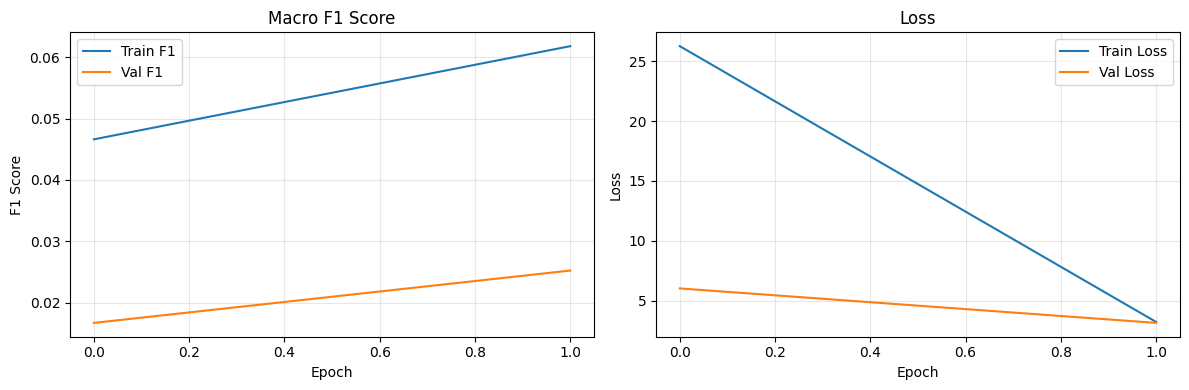


COMPREHENSIVE MODEL EVALUATION

Evaluating Train Set


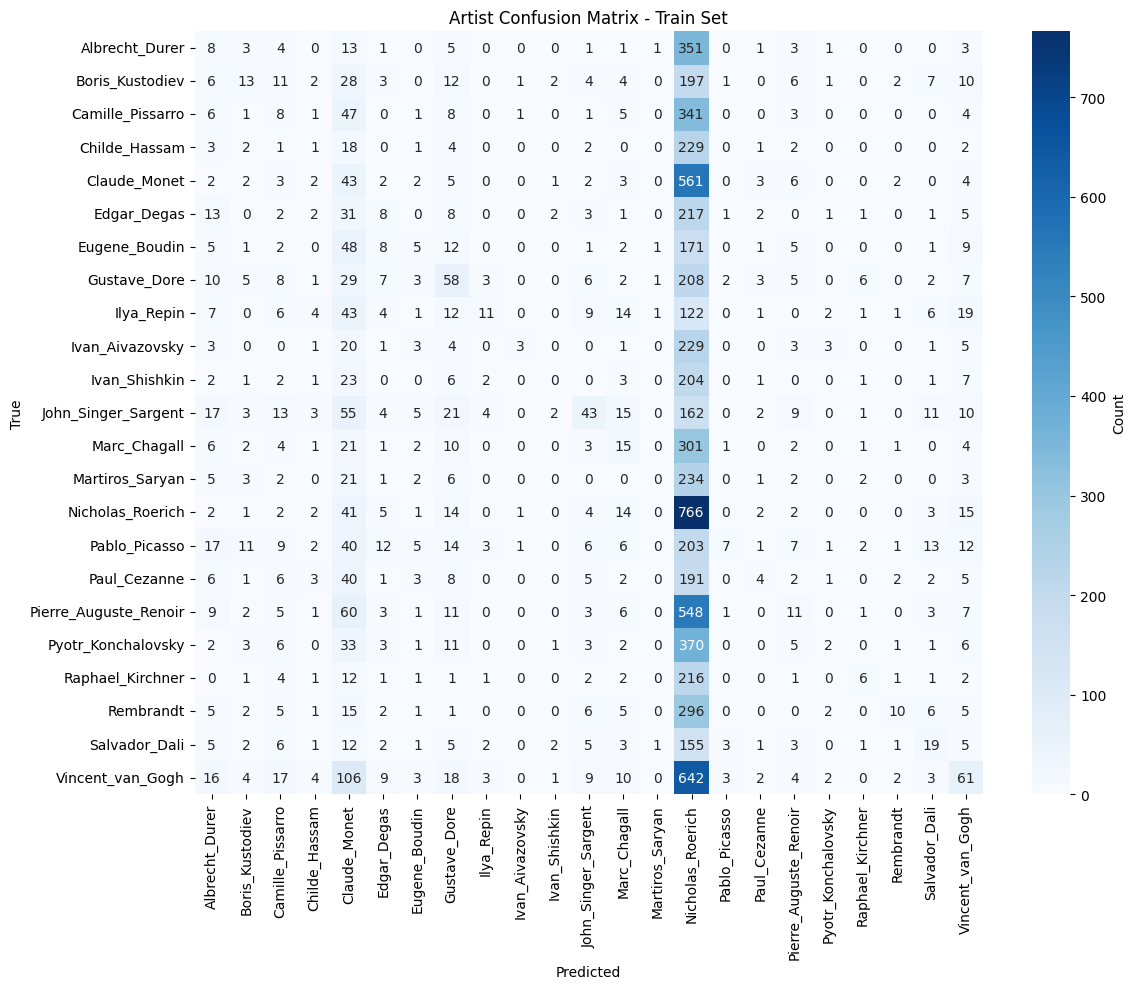


Classification Report (Train Set):
                       precision    recall  f1-score   support

       Albrecht_Durer       0.05      0.02      0.03       396
      Boris_Kustodiev       0.21      0.04      0.07       310
     Camille_Pissarro       0.06      0.02      0.03       427
        Childe_Hassam       0.03      0.00      0.01       266
         Claude_Monet       0.05      0.07      0.06       643
          Edgar_Degas       0.10      0.03      0.04       298
        Eugene_Boudin       0.12      0.02      0.03       272
         Gustave_Dore       0.23      0.16      0.19       366
           Ilya_Repin       0.38      0.04      0.08       264
      Ivan_Aivazovsky       0.43      0.01      0.02       277
        Ivan_Shishkin       0.00      0.00      0.00       254
  John_Singer_Sargent       0.36      0.11      0.17       380
         Marc_Chagall       0.13      0.04      0.06       375
      Martiros_Saryan       0.00      0.00      0.00       282
     Nicholas_Roer

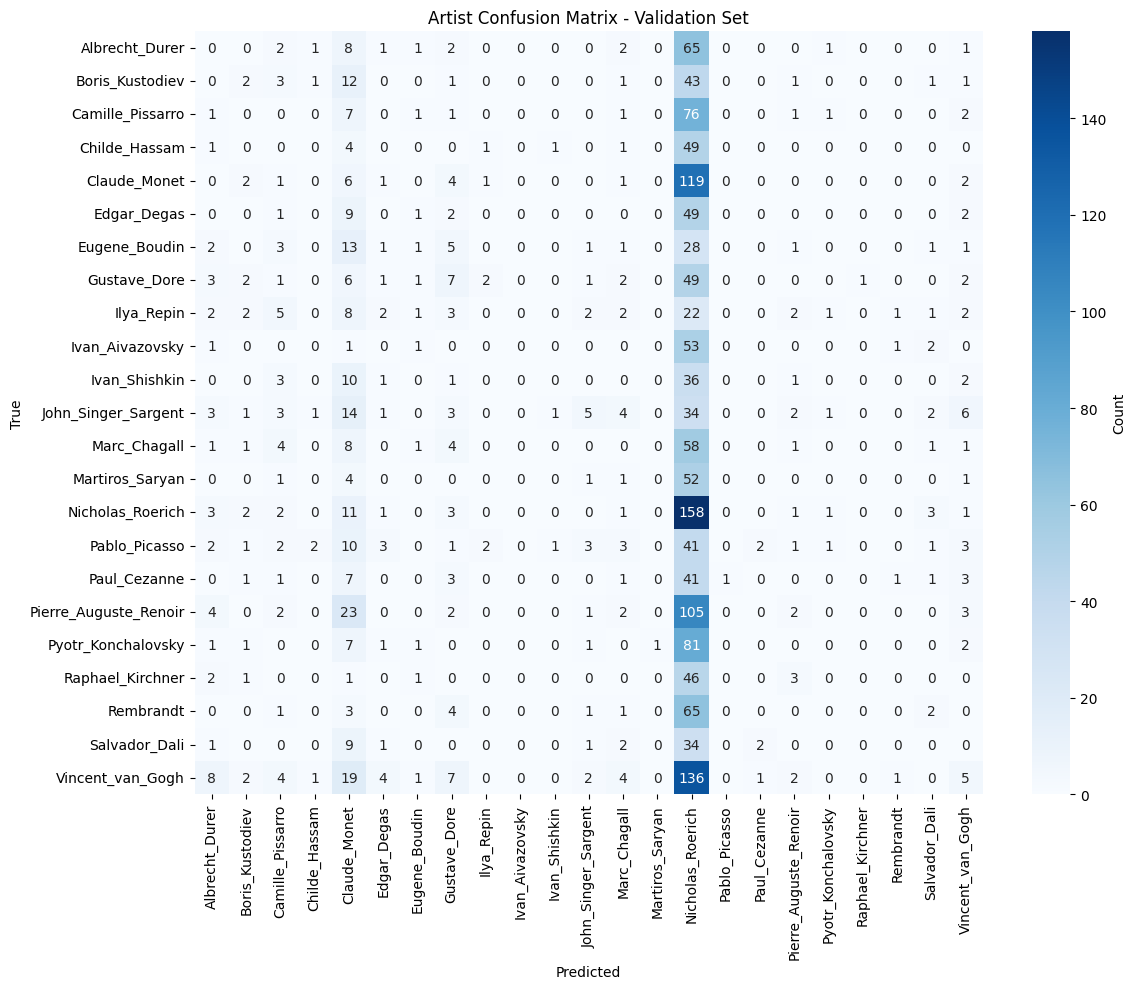


Classification Report (Validation Set):
                       precision    recall  f1-score   support

       Albrecht_Durer       0.00      0.00      0.00        84
      Boris_Kustodiev       0.11      0.03      0.05        66
     Camille_Pissarro       0.00      0.00      0.00        91
        Childe_Hassam       0.00      0.00      0.00        57
         Claude_Monet       0.03      0.04      0.04       137
          Edgar_Degas       0.00      0.00      0.00        64
        Eugene_Boudin       0.09      0.02      0.03        58
         Gustave_Dore       0.13      0.09      0.11        78
           Ilya_Repin       0.00      0.00      0.00        56
      Ivan_Aivazovsky       0.00      0.00      0.00        59
        Ivan_Shishkin       0.00      0.00      0.00        54
  John_Singer_Sargent       0.26      0.06      0.10        81
         Marc_Chagall       0.00      0.00      0.00        80
      Martiros_Saryan       0.00      0.00      0.00        60
     Nicholas

c:\Users\luisb\anaconda3\envs\DeepLearning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luisb\anaconda3\envs\DeepLearning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luisb\anaconda3\envs\DeepLearning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

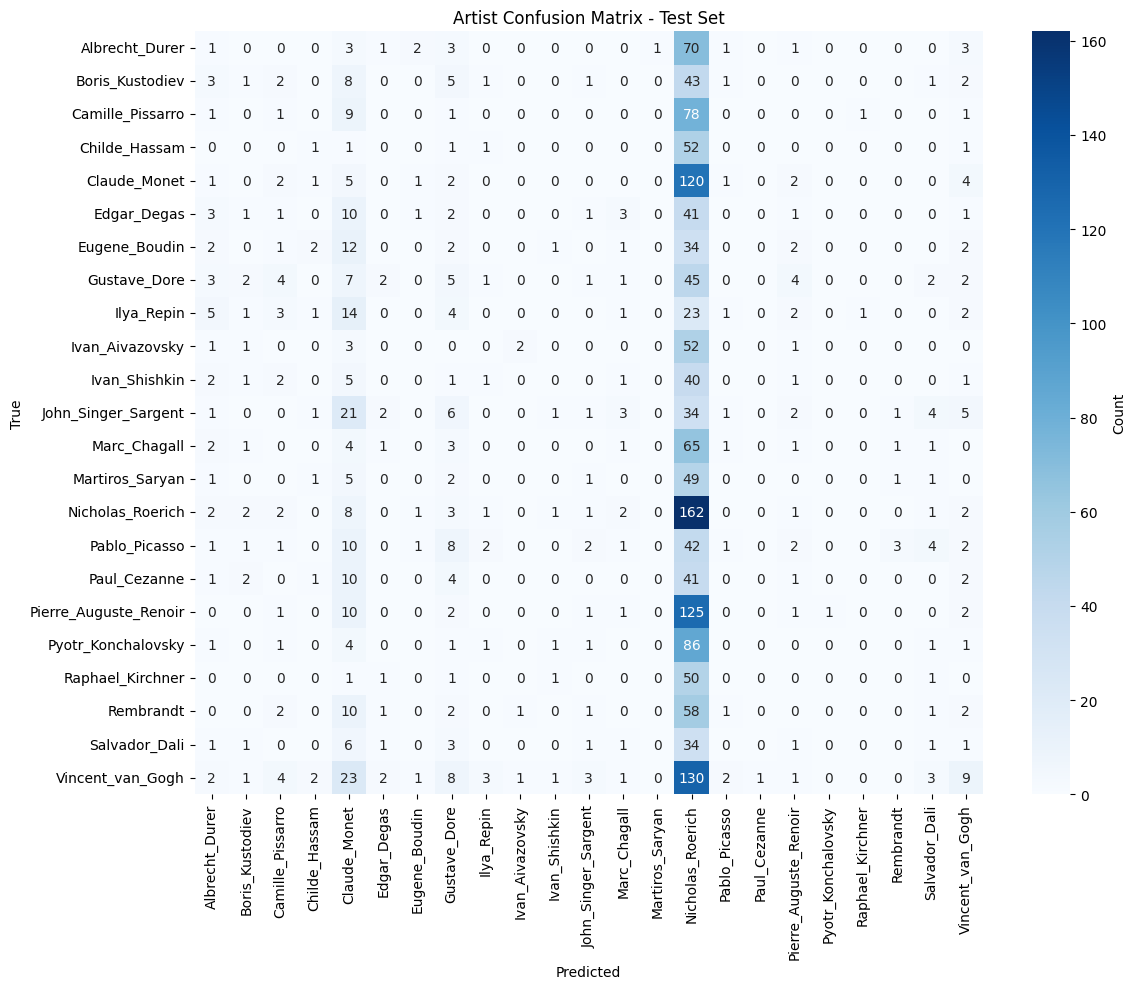


Classification Report (Test Set):
                       precision    recall  f1-score   support

       Albrecht_Durer       0.03      0.01      0.02        86
      Boris_Kustodiev       0.07      0.01      0.02        68
     Camille_Pissarro       0.04      0.01      0.02        92
        Childe_Hassam       0.10      0.02      0.03        57
         Claude_Monet       0.03      0.04      0.03       139
          Edgar_Degas       0.00      0.00      0.00        65
        Eugene_Boudin       0.00      0.00      0.00        59
         Gustave_Dore       0.07      0.06      0.07        79
           Ilya_Repin       0.00      0.00      0.00        58
      Ivan_Aivazovsky       0.50      0.03      0.06        60
        Ivan_Shishkin       0.00      0.00      0.00        55
  John_Singer_Sargent       0.07      0.01      0.02        83
         Marc_Chagall       0.06      0.01      0.02        81
      Martiros_Saryan       0.00      0.00      0.00        61
     Nicholas_Roeri

In [ ]:
# Call the comprehensive evaluation function
evaluate_model_comprehensive(model_uf, history_uf, train_ds, val_ds, test_ds, class_names)

# Over Fitting model

In [ ]:
model_of = tf.keras.Sequential()
model_of.add(tf.keras.layers.Conv2D(32, (5,5), activation='relu', input_shape=IMG_SHAPE))
model_of.add(tf.keras.layers.MaxPooling2D((5,5)))
model_of.add(tf.keras.layers.Flatten())
model_of.add(tf.keras.layers.Dense(128, activation='relu'))

model_of.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
model_of.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=[SparseCategoricalF1Score(num_classes, name="f1_macro")])
model_of.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 46, 46, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2592)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       331,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,303 (1.29 MB)

 Trainable params: 337,303 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Setup Callbacks using the helper function
callbacks = setup_callbacks(
    monitor_metric='val_f1_macro',
    early_stopping_patience=6,
    lr_factor=0.1,
    lr_patience=3,
    min_lr=1e-6
)


history_of = model_of.fit(train_ds,
                              validation_data=val_ds,
                              epochs=2,
                              batch_size= BATCH_SIZE, 
                              callbacks= callbacks, 
                              class_weight=None)

Epoch 1/2
145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - f1_macro: 0.0476 - loss: 67.7772 - val_f1_macro: 0.0167 - val_loss: 6.0167 - learning_rate: 0.0010
Epoch 2/2
145/145 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - f1_macro: 0.0368 - loss: 3.2765 - val_f1_macro: 0.0252 - val_loss: 3.1383 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.


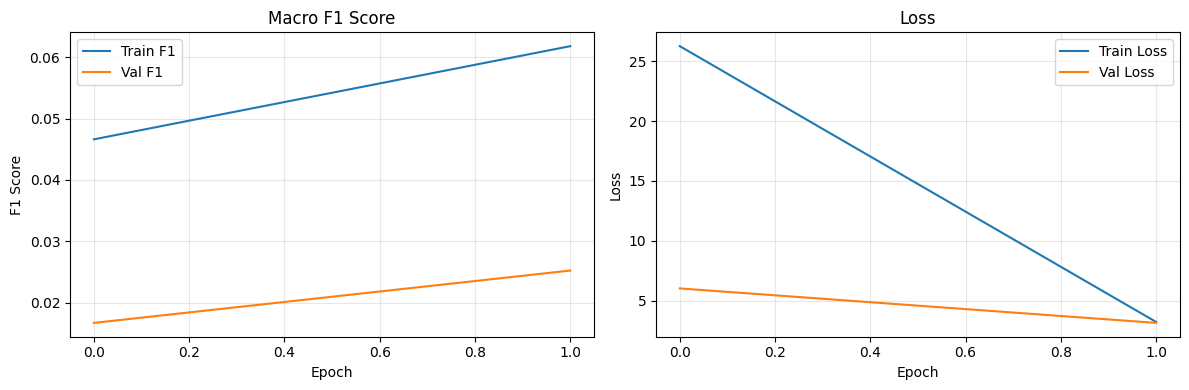


COMPREHENSIVE MODEL EVALUATION

Evaluating Train Set


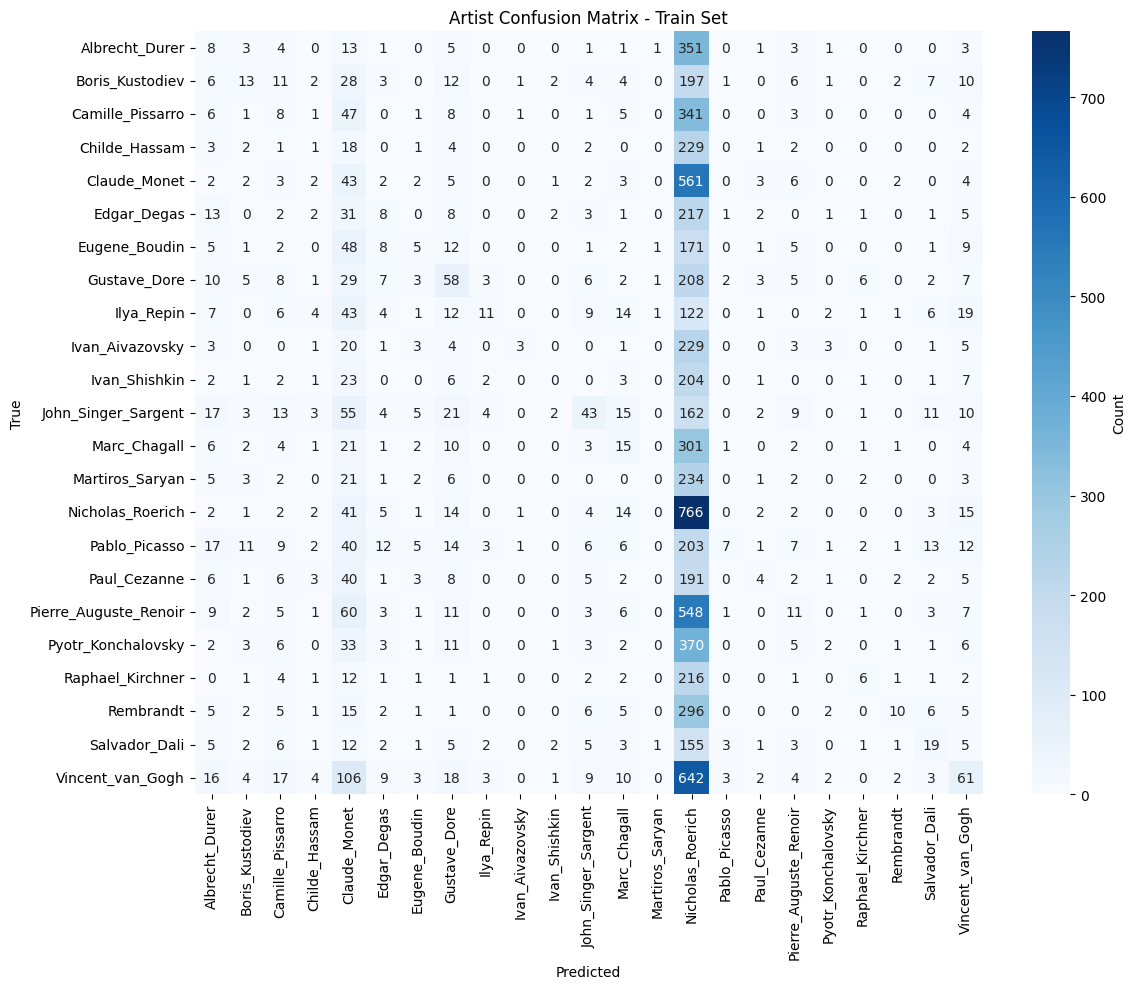


Classification Report (Train Set):
                       precision    recall  f1-score   support

       Albrecht_Durer       0.05      0.02      0.03       396
      Boris_Kustodiev       0.21      0.04      0.07       310
     Camille_Pissarro       0.06      0.02      0.03       427
        Childe_Hassam       0.03      0.00      0.01       266
         Claude_Monet       0.05      0.07      0.06       643
          Edgar_Degas       0.10      0.03      0.04       298
        Eugene_Boudin       0.12      0.02      0.03       272
         Gustave_Dore       0.23      0.16      0.19       366
           Ilya_Repin       0.38      0.04      0.08       264
      Ivan_Aivazovsky       0.43      0.01      0.02       277
        Ivan_Shishkin       0.00      0.00      0.00       254
  John_Singer_Sargent       0.36      0.11      0.17       380
         Marc_Chagall       0.13      0.04      0.06       375
      Martiros_Saryan       0.00      0.00      0.00       282
     Nicholas_Roer

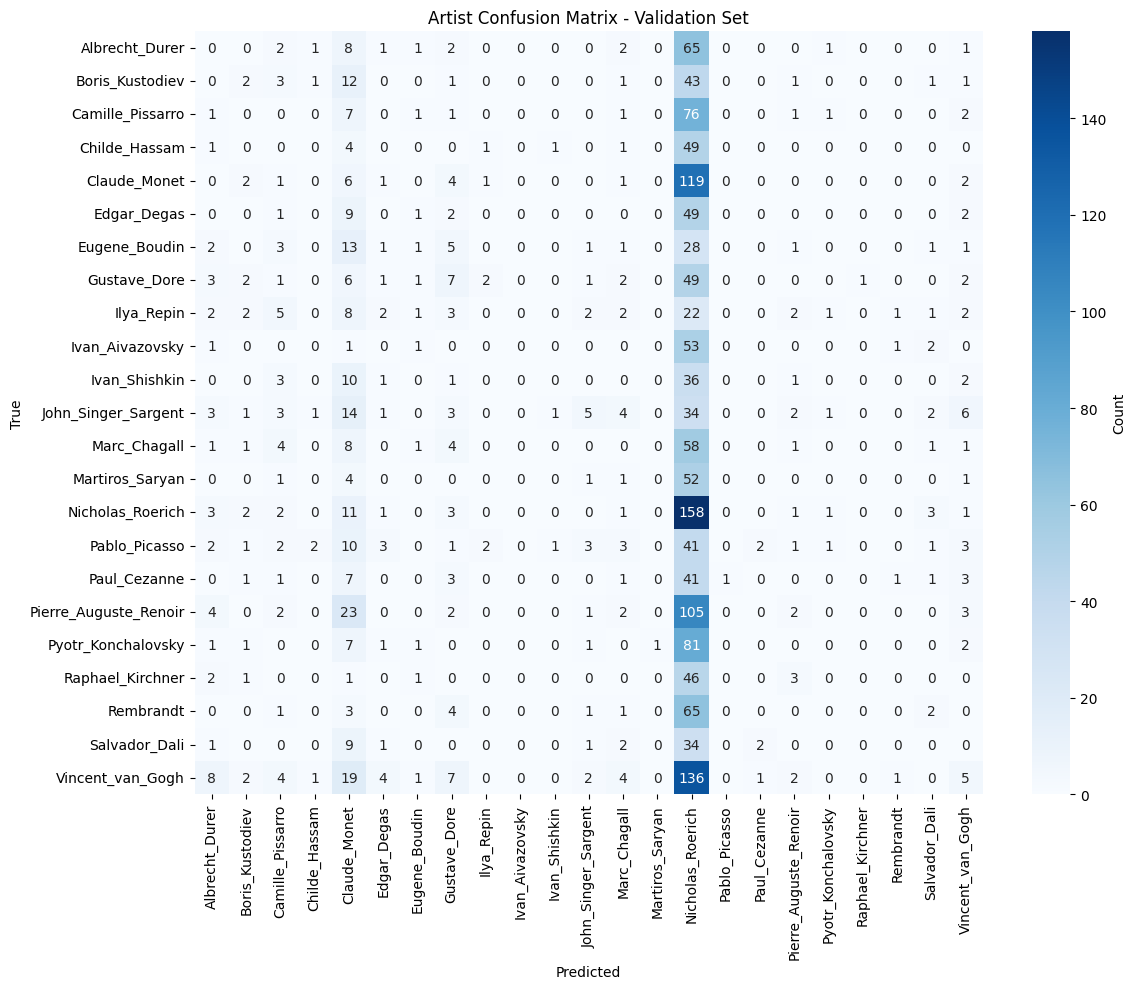


Classification Report (Validation Set):
                       precision    recall  f1-score   support

       Albrecht_Durer       0.00      0.00      0.00        84
      Boris_Kustodiev       0.11      0.03      0.05        66
     Camille_Pissarro       0.00      0.00      0.00        91
        Childe_Hassam       0.00      0.00      0.00        57
         Claude_Monet       0.03      0.04      0.04       137
          Edgar_Degas       0.00      0.00      0.00        64
        Eugene_Boudin       0.09      0.02      0.03        58
         Gustave_Dore       0.13      0.09      0.11        78
           Ilya_Repin       0.00      0.00      0.00        56
      Ivan_Aivazovsky       0.00      0.00      0.00        59
        Ivan_Shishkin       0.00      0.00      0.00        54
  John_Singer_Sargent       0.26      0.06      0.10        81
         Marc_Chagall       0.00      0.00      0.00        80
      Martiros_Saryan       0.00      0.00      0.00        60
     Nicholas

c:\Users\luisb\anaconda3\envs\DeepLearning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luisb\anaconda3\envs\DeepLearning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luisb\anaconda3\envs\DeepLearning\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

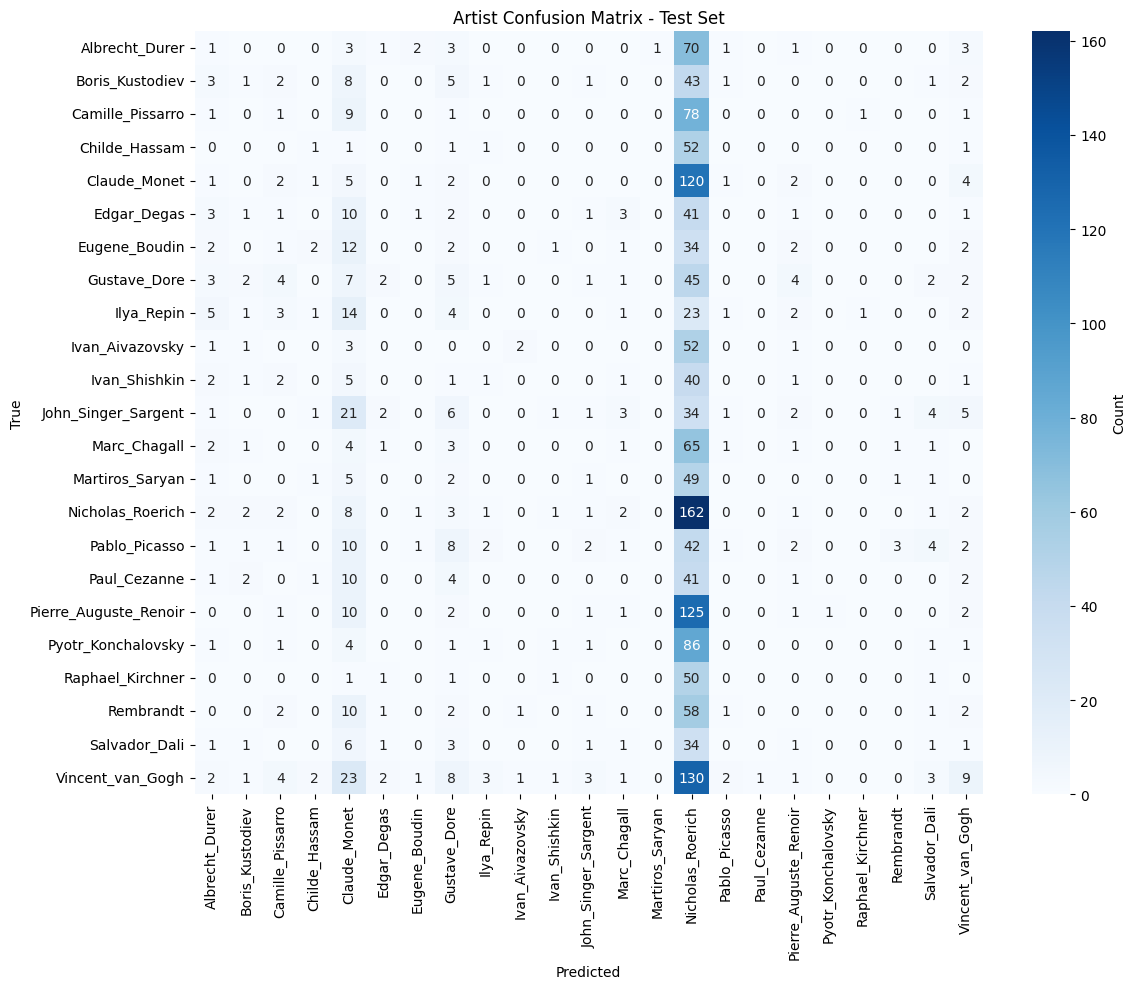


Classification Report (Test Set):
                       precision    recall  f1-score   support

       Albrecht_Durer       0.03      0.01      0.02        86
      Boris_Kustodiev       0.07      0.01      0.02        68
     Camille_Pissarro       0.04      0.01      0.02        92
        Childe_Hassam       0.10      0.02      0.03        57
         Claude_Monet       0.03      0.04      0.03       139
          Edgar_Degas       0.00      0.00      0.00        65
        Eugene_Boudin       0.00      0.00      0.00        59
         Gustave_Dore       0.07      0.06      0.07        79
           Ilya_Repin       0.00      0.00      0.00        58
      Ivan_Aivazovsky       0.50      0.03      0.06        60
        Ivan_Shishkin       0.00      0.00      0.00        55
  John_Singer_Sargent       0.07      0.01      0.02        83
         Marc_Chagall       0.06      0.01      0.02        81
      Martiros_Saryan       0.00      0.00      0.00        61
     Nicholas_Roeri

In [ ]:
# Call the comprehensive evaluation function
evaluate_model_comprehensive(model_of, history_of, train_ds, val_ds, test_ds, class_names)

# Hyperparameter tuning

In [ ]:
def reg_wrapper(type: str, value: float):

    """
    This function is a wrapper for regularization methods.

    Parameters
    ----------
        -type : str
            Type of regularization passed as string.

        -value : float
            Value of the regularization.

    Returns
    -------
        -regularization
            Regularization method.

    """
    if type == 'l2':
        return L2(value)
    if type == 'l1':
        return L1(value)
    return None


def opt_wrapper(type: str, lr: float):

    """
    This function is a wrapper for optimization methods.

    Parameters
    ----------
        -type : str
            Optimizer passed as string.

        -lr : float
            Value of the learning rate.

    Returns
    -------
        -Optimizer
            Optimizer method.


    """

    if type == 'RMSprop':
        return RMSprop(learning_rate=lr)
    if type == 'Adam':
        return Adam(learning_rate=lr)
    if type == 'Adadelta':
        return Adadelta(learning_rate=lr)
    if type == 'Adagrad':
        return Adagrad(learning_rate=lr)


In [ ]:
def build_model_multiclass(hp):
    """
    Builds model and sets up hyperparameter space to search.

    Parameters
    ----------
    hp : HyperParameter object
        Configures hyperparameters to tune.

    Returns
    -------
    model : keras model
        Compiled model with hyperparameters to tune.
    """
    
    # Initialize sequential model and start building model.
    model = Sequential()
    
    # Tune the number of Convolution blocks
    num_conv_blocks = hp.Int("num_conv_blocks", min_value=1, max_value=3)
    regularizer = reg_wrapper(hp.Choice('type', ['l1', 'l2', 'none']), hp.Choice('reg_value', [0.001 , 0.01, 0.0]))
    
    # Tune activation function for conv layers
    conv_activation = hp.Choice('conv_activation', ['relu', 'tanh', 'sigmoid'])
    
    # Tune batch normalization choice
    use_batch_norm = hp.Boolean('use_batch_norm')
    
    for i in range(1, num_conv_blocks):
        filter_size = hp.Int('filter_size_' + str(i), min_value=3, max_value=5, step=1)
        strides_conv = hp.Int('stride_conv' + str(i), min_value=1, max_value=2)
        n_filters = hp.Int('n_filters_' + str(i), min_value=32, max_value=80, step=16)
        padding_conv = hp.Choice('padding_conv' + str(i), values=['same', 'valid'])
        
        # Tune the number of layers in each Convolution block
        conv_block_size = hp.Int("size_conv_block" + str(i), min_value=1, max_value=3)
        
        for k in range(1, conv_block_size):
            model.add(Conv2D(filters=n_filters,
                         kernel_size=filter_size,
                         strides=strides_conv,
                         padding=padding_conv,
                         activation=conv_activation))
            
            # Add batch normalization if selected
            if use_batch_norm:
                model.add(BatchNormalization())
        
        pooling_size = hp.Int('Pooling_size' + str(i), min_value=3, max_value=5)
        strides_pool = hp.Int('stride_pool' + str(i), min_value=1, max_value=2)
        model.add(MaxPooling2D(pool_size=pooling_size,
                               strides=strides_pool))
    
    # Tune choice between GlobalAveragePooling and Flatten
    pooling_choice = hp.Choice('pooling_choice', ['global_avg_pooling', 'flatten'])
    
    if pooling_choice == 'global_avg_pooling':
        model.add(GlobalAveragePooling2D())
    else:
        model.add(Flatten())
    
    # Tune the number of hidden layers and units in each.
    # The basic for loop for including several layers
    for j in range(1, hp.Int("num_layers", min_value=1, max_value=3)):  
        units = hp.Int("units_" + str(j), min_value=24, max_value=124, step=16)
        model.add(Dense(units=units,
                        activation="relu",
                        kernel_regularizer=regularizer))
        
        # Add batch normalization if selected
        if use_batch_norm:
            model.add(BatchNormalization())
        
        # Dropout following the previous dense layer means that after each layer we would have a dropout
        # Tune dropout layer with values from 0 - 0.5 with stepsize of 0.1.
        dropout = hp.Float("dropout_" + str(j), min_value=0, max_value=0.5, step=0.1)
        model.add(Dropout(dropout))

    # Add output layer.
    model.add(Dense(units=num_classes, activation="softmax"))

    # Tune learning rate for Adam optimizer with values from 0.01, 0.001, or 0.0001
    hp_learning_rate = hp.Choice("learning_rate", values=[0.01, 0.001, 0.0001])

    # You can change the optimizer to others
    hp_optimizer = hp.Choice("Optimizer", values=['Adam', 'Adagrad', 'Adadelta', 'RMSprop'])

    # Define optimizer, loss, and metrics
    model.compile(optimizer=opt_wrapper(hp_optimizer, hp_learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=[SparseCategoricalF1Score(num_classes, name="f1_macro")])
    
    return model


In [ ]:
# Setup Callbacks using the helper function
callbacks = setup_callbacks(
    monitor_metric='val_f1_macro',
    early_stopping_patience=6,
    lr_factor=0.1,
    lr_patience=3,
    min_lr=1e-6
)

In [ ]:
# Batch size configuration for hyperparameter search
HP_BATCH_SIZE = 64

tuner_multiclass = kt.Hyperband(build_model_multiclass, # the hypermodel
                     objective='val_loss',  # Our main monitoring metric
                     max_epochs=50,
                     factor=10,
                     project_name='HP_CM', # You can name the project itself
                     seed=42)

In [ ]:
tuner_multiclass.search(train_ds, 
                        epochs=50, 
                        validation_data=val_ds,
                        callbacks=callbacks,
                        verbose=1)

In [ ]:
best_parameters_multiclass= tuner_multiclass.get_best_hyperparameters()[0]
print(best_parameters_multiclass.values)

In [ ]:
model= tuner_multiclass.hypermodel.build(best_parameters_multiclass)

In [ ]:
all_labels = np.concatenate([y.numpy() for _, y in train_ds])
classes = np.unique(all_labels)
weights = compute_class_weight("balanced", classes=classes, y=all_labels)
class_weight_dict = dict(zip(classes.astype(int), weights))